# Backpropagation Example

This example demonstrates forward and backward pass in a neural network.

The network consists of:

- 3 input neurons
- 2 hidden neurons
- 1 output neuron

---

## Forward Pass

Hidden layer:

$$
h = \sigma(XW_1 + b_1)
$$

Output layer:

$$
y = \sigma(hW_2 + b_2)
$$

---

## Backward Pass

Error:

$$
E = t - y
$$

Output gradient:

$$
\delta_o = E \cdot \sigma'(y)
$$

Hidden gradient:

$$
\delta_h = \delta_o W_2^T \cdot \sigma'(h)
$$

Epoch 1, Output: [[0.42444814]], Loss: 0.331259943501892
Epoch 2, Output: [[0.46826268]], Loss: 0.28274457661412766
Epoch 3, Output: [[0.50953862]], Loss: 0.24055236387288875
Epoch 4, Output: [[0.54737439]], Loss: 0.20486993967144612
Epoch 5, Output: [[0.5813847]], Loss: 0.17523876971774086
Epoch 6, Output: [[0.61157948]], Loss: 0.15087050238280522
Epoch 7, Output: [[0.63821057]], Loss: 0.13089158867068731
Epoch 8, Output: [[0.66164452]], Loss: 0.11448443092793431
Epoch 9, Output: [[0.68227841]], Loss: 0.10094701138339418
Epoch 10, Output: [[0.70049307]], Loss: 0.08970439952988506

Final Output: [[0.70049307]]


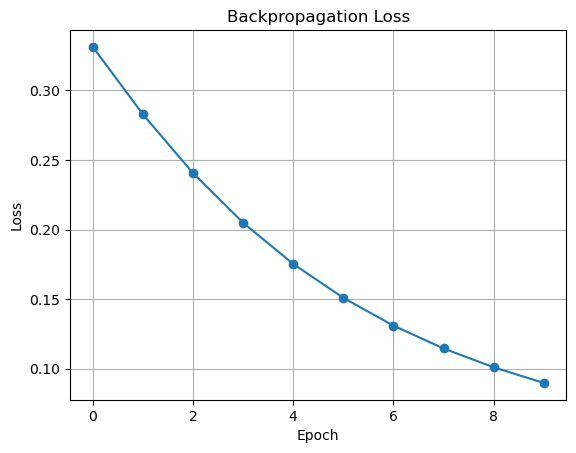

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input (from diagram)
x = np.array([[1, 0, 1]])   # x1=1, x2=0, x3=1

# Target output
target = np.array([[1]])

# Learning rate
lr = 0.9

# -------- Initial Weights (from your image) --------
# Input → Hidden
w14 = 0.2
w15 = -0.3
w24 = 0.4
w25 = 0.1
w34 = -0.5
w35 = 0.2

# Hidden → Output
w46 = -0.3
w56 = -0.2

# Biases
b4 = -0.4
b5 = 0.2
b6 = -0.1

# Convert to matrices
W1 = np.array([[w14, w15],
               [w24, w25],
               [w34, w35]])

W2 = np.array([[w46],
               [w56]])

b1 = np.array([[b4, b5]])
b2 = np.array([[b6]])

# Sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

loss_history = []

# Train for few iterations
for epoch in range(10):

    # -------- Forward Pass --------
    z1 = np.dot(x, W1) + b1
    h = sigmoid(z1)

    z2 = np.dot(h, W2) + b2
    y_pred = sigmoid(z2)

    # Loss
    error = target - y_pred
    loss = np.mean(error**2)
    loss_history.append(loss)

    # -------- Backward Pass --------
    d_output = error * sigmoid_derivative(y_pred)

    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(h)

    # -------- Update --------
    W2 += h.T.dot(d_output) * lr
    W1 += x.T.dot(d_hidden) * lr

    b2 += np.sum(d_output) * lr
    b1 += np.sum(d_hidden, axis=0) * lr

    print(f"Epoch {epoch+1}, Output: {y_pred}, Loss: {loss}")

print("\nFinal Output:", y_pred)

# -------- Loss Visualization --------
plt.plot(loss_history, marker='o')
plt.title("Backpropagation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Algorithm: Backpropagation

Step 1: Initialize weights and biases

Step 2: Input data and target output

Step 3: Forward Pass

    a) Compute hidden layer:
       h = σ(XW₁ + b₁)

    b) Compute output:
       y = σ(hW₂ + b₂)

Step 4: Compute Error

    error = target - output

Step 5: Backward Pass

    a) Compute output gradient:
       δo = error * σ'(y)

    b) Compute hidden gradient:
       δh = δo * W₂ * σ'(h)

Step 6: Update Weights

    W₂ = W₂ + η * hᵀ * δo  
    W₁ = W₁ + η * Xᵀ * δh  

Step 7: Update Bias

    b₂ = b₂ + η * δo  
    b₁ = b₁ + η * δh  

Step 8: Repeat for epochs

Step 9: Output final result